# Lab 7A &middot; k-NN on street photographs

BITS F459 Computer Vision &middot; **Notebook A of 2**

## Your goal

In the walkthrough you saw k-NN label one street photograph, step by step. Here you do the same
on a **different photograph**, (a) below, and then on four more. By the end of Section 7 you will
have produced a map like (b): every 20 &times; 20 patch labelled **sky**, **road** or **tree** by a
k-NN that you wrote, trained on patches that you labelled.

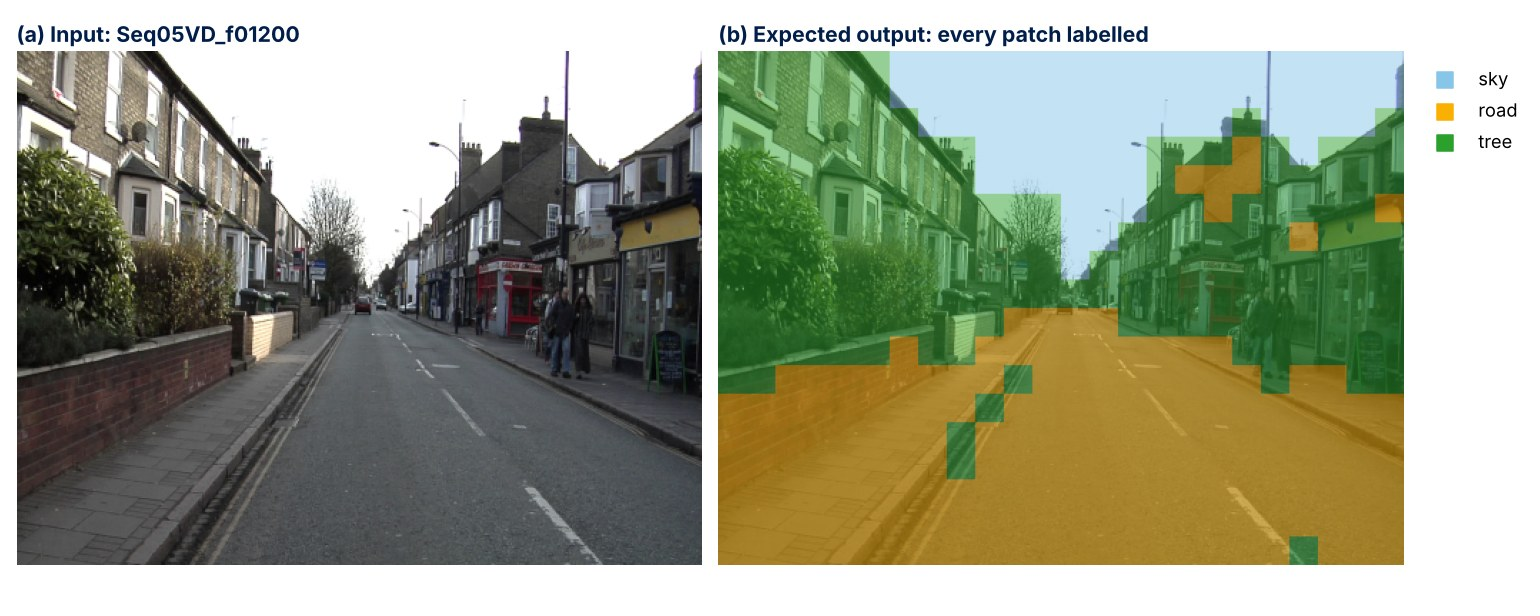

Your map will not be identical to (b), because your labelled patches will differ. It should look
broadly the same.

## How this notebook works

- Every section is an instruction, followed by an **empty code cell**. You write all the code.
  You may adapt the walkthrough's code, or write your own.
- Every section ends with **What you should see**. Check your output against it before you move
  on; every later section uses the earlier ones.
- **Explore** boxes ask you to change something, look at what happens, and record it.
- Use the variable names given in **bold**. The checker reads them from the line your last cell
  prints, and recomputes every value from your own patches.
- Do not use a ready-made k-NN until Section 10.

| Item | Sections | Marks |
|:--|:--|:--|
| A-map: your labelled patches and your map of the photograph | 4, 7 | 1 |
| A-table: the patch you follow, validation accuracies and the three choices | 6, 7, 8 | 1 |
| A-multi: the classifier on other photographs, and your fix | 9 | 1 |

Lab 7 is 10 marks: 3 here and 7 in Notebook B.

## 1 &middot; Load the photograph

**What to do**
1. Set **`BITS_ID`** to your BITS ID as a string, exactly as on your ID card.
2. Download two files from the CamVid copy on GitHub and save them:
   - the photograph `https://raw.githubusercontent.com/alexgkendall/SegNet-Tutorial/master/CamVid/test/Seq05VD_f01200.png`
   - its human labels `https://raw.githubusercontent.com/alexgkendall/SegNet-Tutorial/master/CamVid/testannot/Seq05VD_f01200.png`

   If GitHub's CamVid copy does not open, the same files are in the course repository under
   `labs/lab07/images/` (the labels file ends in `_labels.png`).
3. Load the photograph as an RGB NumPy array **`RGB`**, and the label image as a NumPy array
   **`LAB`**. Set **`PHOTO = "Seq05VD_f01200"`**.
4. Print both shapes, and display the photograph.

It is worth writing a function `load(name)` that does steps 2 and 3 for any CamVid name: you
will use it again in Section 9.

**What you should see**
- `RGB.shape` is `(360, 480, 3)` and `LAB.shape` is `(360, 480)`.
- `LAB` holds class numbers, one per pixel. The three you use are **0 sky, 3 road, 5 tree**.
- The photograph (a) above.

## 2 &middot; From pixels to edges

**What to do**
1. Make the grey image, grey = 0.299 R + 0.587 G + 0.114 B, as floating-point numbers.
2. Run Sobel on the **whole** grey image: Gx with the kernel [[&minus;1, 0, 1], [&minus;2, 0, 2], [&minus;1, 0, 1]],
   Gy with its transpose, repeating the edge pixels at the border (`mode="nearest"` in
   `scipy.ndimage.convolve`). Divide both by 8. Edge strength = &radic;(Gx&sup2; + Gy&sup2;).
3. Set **`THRESH = 20`**. A pixel is an edge pixel when its strength is above `THRESH`.
4. Show six panels: the grey image, |Gx|, |Gy|, the edge strength, the edge pixels (white), and
   the photograph. Print the percentage of all pixels that are edge pixels.

**What you should see**
- Grey values run from about 1 to 255, and edge strength from 0 to about 115.
- With `THRESH = 20`, **12.6%** of all pixels are edge pixels.

> **Explore 1 &middot; the threshold.** Run your Section 2 code with `THRESH = 10`, then with
> `THRESH = 40`, and compare the edge-pixel panel and the percentage each time. **Put it back to 20**
> and run Section 2 again before you go on.
>
> **What you should see:** about **24.9%** edge pixels at 10 and about **4.4%** at 40.
>
> **Record** in **`EXPLORE_1`**, as a string of one sentence: which parts of the photograph gain or
> lose edge pixels as the threshold changes.

## 3 &middot; Two numbers for every patch

The photograph is cut into 432 patches of 20 &times; 20 pixels, 24 across and 18 down, numbered row by
row from 0 at the top left: **patch number = 24 &times; row + column**. Here is every number on this
photograph:

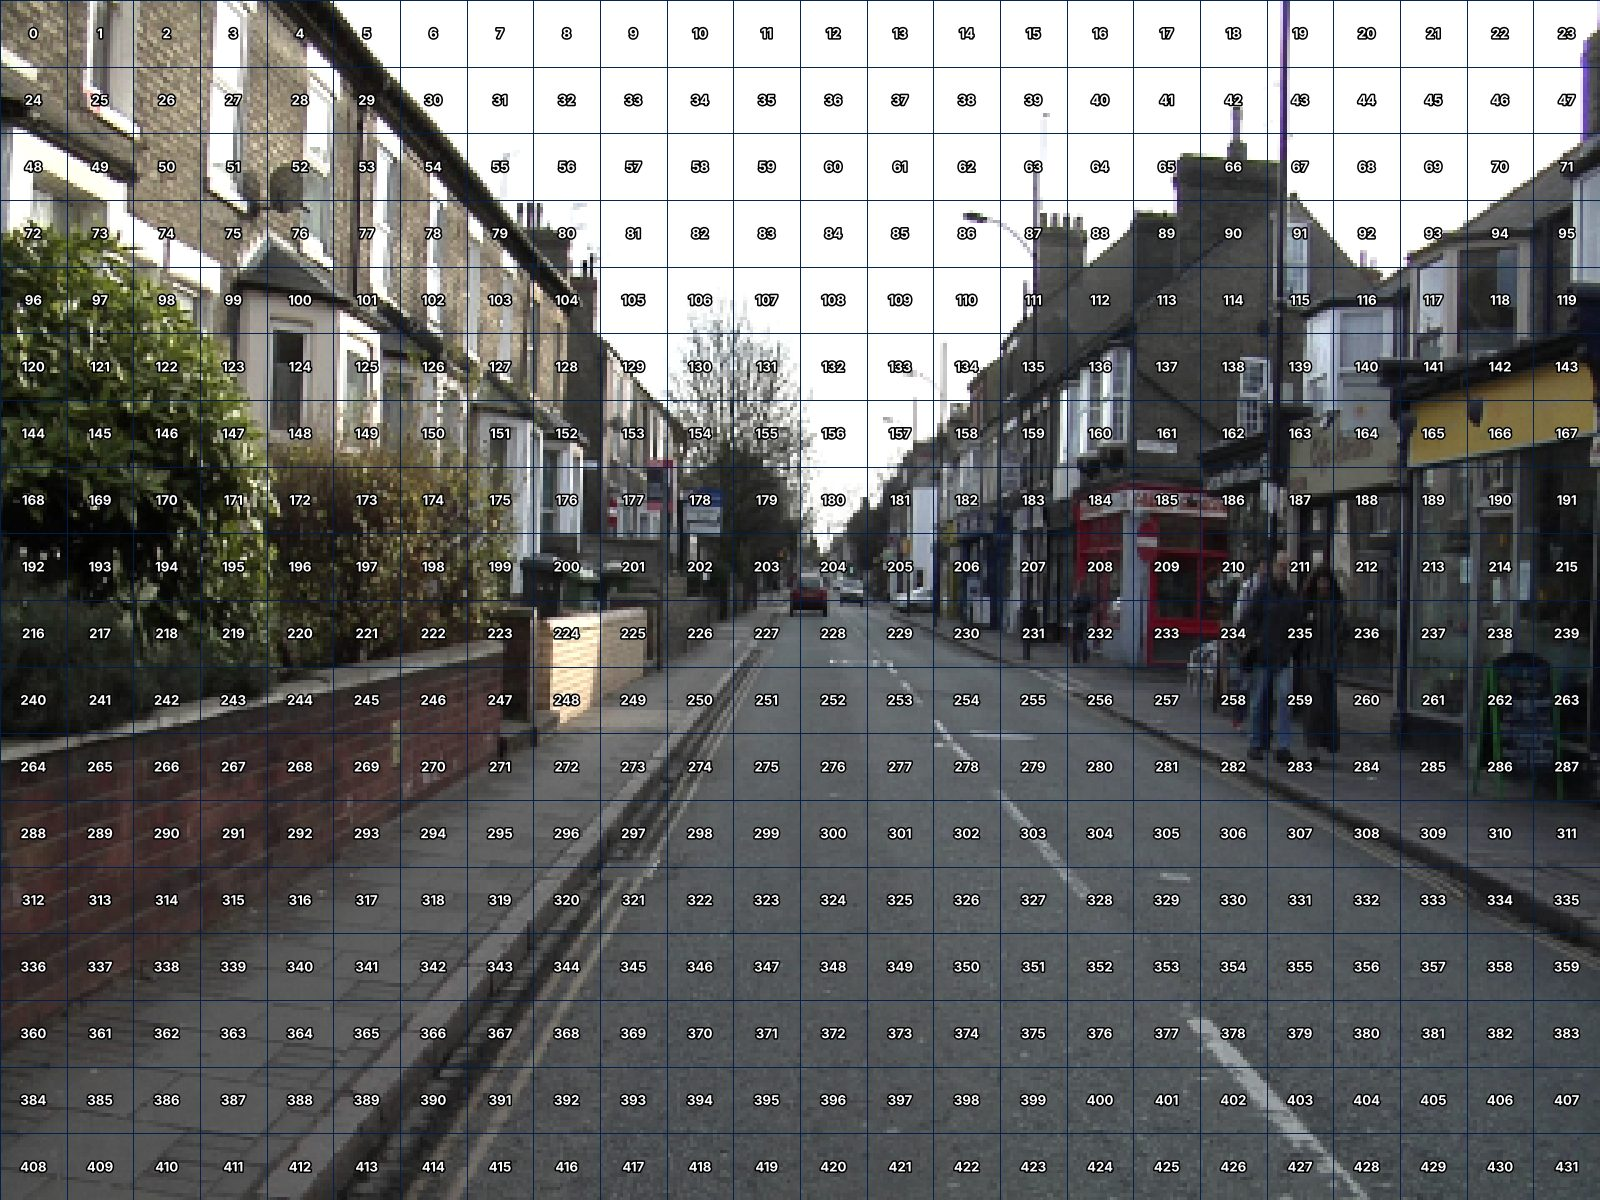

**What to do**
1. For every patch p from 0 to 431 compute
   - x&#8321;, brightness = (mean of its 400 grey values) &divide; 25
   - x&#8322;, texture = (number of its 400 pixels that are edge pixels) &divide; 40

   and store them in a NumPy array **`F`** of shape (432, 2), row p for patch p.
2. Make **`TRUTH`**, a list of 432 entries: `"sky"`, `"road"` or `"tree"` when at least 70% of the
   patch's pixels in `LAB` carry that class (0, 3 or 5), otherwise `None`. It is used only to score
   your maps.
3. Show `F` as a table (patch, row, column, x&#8321;, x&#8322;), and write each patch's x&#8321; and x&#8322;
   onto the photograph, as the walkthrough does.

**What you should see**

| patch | what it shows | x&#8321; | x&#8322; |
|:--|:--|:--|:--|
| 16 | sky | 10.20 | 0.00 |
| 350 | road | 3.70 | 0.00 |
| 148 | hedge (tree) | 4.25 | 1.725 (69 edge pixels) |

- `F.shape` is `(432, 2)`; x&#8321; runs from about 0.7 to 10.2, x&#8322; from 0 to about 6.9.
- `TRUTH` has **65** sky, **108** road and **46** tree patches: 219 patches that can be scored.

> **Explore 2 &middot; inside a patch.** Choose **one** patch that is clearly sky, **one** clearly road
> and **one** clearly tree from the grid, and put their numbers in a list **`MY_PATCHES`**. For each
> one, show its 400 grey values and its 400 edge-strength values as numbers, with the edge pixels
> marked, and print how x&#8321; and x&#8322; follow from them.
>
> **What you should see**, for patch 148: mean grey = 42,463.0 / 400 = 106.16, so x&#8321; = 4.25; 69
> edge pixels, so x&#8322; = 69 / 40 = 1.725.

## 4 &middot; Label your own patches

**What to do**
1. Using the numbered grid in Section 3, choose patches that are **clearly** one class: nearly all
   of the patch shows sky, or road, or tree. Avoid walls, windows, cars and people.
   - **`TRAIN`**: a dictionary with keys `"sky"`, `"road"`, `"tree"`, each a list of **8** patch numbers
   - **`VAL`**: the same keys, each with **4 further** patch numbers, none of them in `TRAIN`
2. Print the counts, check that all 36 numbers are different, and outline your patches on the
   photograph: solid for training, dashed for validation, coloured by class.

**What you should see**
- 8, 8, 8 in `TRAIN` and 4, 4, 4 in `VAL`; 36 different numbers from 0 to 431.
- Every outline sits on a patch that is clearly its class. The checker compares your choices with
  the human labels, and allows at most 3 of the 36 to be unclear.

## 5 &middot; Feature space

**What to do**
1. Build **`Xtr`** (shape 24 &times; 2) and **`ytr`** (24 labels) from your `TRAIN` patches, taking the
   classes in the order **sky, road, tree** and, within each class, the patches in the order you
   listed them. Build **`Xva`** and **`yva`** from `VAL` the same way.
2. Plot all 432 patches as small grey points in (x&#8321;, x&#8322;), your training patches as large
   coloured dots and your validation patches as coloured rings.

**What you should see**
- `Xtr.shape` is `(24, 2)`, `Xva.shape` is `(12, 2)`, and `ytr` starts with eight `"sky"`.
- Sky at the far right with x&#8322; near 0, road on the left with x&#8322; near 0, tree above the road
  with x&#8322; between about 1 and 5. On this photograph the trees are mostly dark hedges, so they
  sit closer to the road than the bare trees did in the walkthrough.

> **Explore 3.** Find a validation ring that sits closer to another class's dots than to its own.
> Look at that patch on the photograph.

## 6 &middot; Your k-NN, and one patch followed through it

**What to do**
1. Write **`distances(Xtr, q, metric="L2")`**, **`knn_one(Xtr, ytr, q, k, metric="L2")`** and
   **`knn_predict(Xtr, ytr, Xq, k, metric="L2")`**, which returns one label per row of `Xq`.
   - L2 is &radic;&Sigma;(a &minus; b)&sup2; and L1 is &Sigma;|a &minus; b|.
   - Sort the training points by distance; equal distances keep the order of `Xtr`.
   - Keep the k nearest and count their labels; the most votes wins.
   - If labels tie for the most votes, return the label of the **nearest** point among the tied labels.
2. Check it on the five cases in the table below. Training points `[[0, 0], [3, 0], [0, 4], [6, 6], [1, 1]]`
   with labels `["sky", "road", "tree", "tree", "road"]`, called #1 to #5, except in the last two rows.

| query | k | metric | expected | why |
|:--|:--|:--|:--|:--|
| (1, 0) | 1 | L2 | sky | #1 and #5 are both 1 away; #1 comes first |
| (1, 0) | 3 | L2 | road | #1 sky, #5 road, #2 road: road 2, sky 1 |
| (0, 2) | 2 | L2 | road | #5 road is nearest; #1 and #3 tie at 2, #1 first; road and sky tie 1 to 1, road is nearer |
| (0, 0) | 1 | L2 | tree | training points (3, 0) road and (2, 2) tree: 2.83 against 3 |
| (0, 0) | 1 | L1 | road | the same two points: 4 against 3 |

3. With your training patches, label all 432 patches with k = 1 and with k = 3. Print the list of
   patches, not in `TRAIN`, whose label differs between the two.

> **Explore 4 &middot; follow one patch.** Choose one patch from that list as **`DISAGREE_PATCH`**. Print
> its five nearest training patches with their labels and distances, and draw the patch and its
> three nearest training patches on the photograph and in feature space.

**What you should see**
- All five check cases give the expected label.
- The list holds roughly 10 to 40 patches, depending on your training patches.
- For your patch, the nearest training patch has one label and the three nearest vote for another.

## 7 &middot; Choose k, and colour the photograph

**What to do**
1. Draw the decision regions in feature space for k = 1, 3 and 7: label a fine grid of points and
   colour each by its label, with your training patches on top.
2. With metric L2, train on `Xtr`, `ytr` and predict `Xva` for k = 1, 3, 5, 7. Store the accuracies
   (fractions between 0 and 1) in **`VAL_ACC`** = `{1: ..., 3: ..., 5: ..., 7: ...}`. Set **`CHOSEN_K`** to
   the k with the highest accuracy, the smallest such k on a tie.
3. Label all 432 patches with `CHOSEN_K` as the list **`MAP_PRED`**. Score it: the fraction of the 219
   patches with a `TRUTH` label that `MAP_PRED` gets right.
4. Show three pictures: your map (each patch tinted by its label), the human labels from `TRUTH`, and
   your map with the wrong patches outlined in red.

**What you should see**
- Validation accuracies mostly between 0.83 and 1.0; `CHOSEN_K` is usually 1.
- A map like (b) at the top, right on about **95% to 100%** of the 219 scored patches.
- Walls, windows and cars get one of the three labels; they are not scored.

> **Explore 5.** Swap one of your `TRAIN` tree patches for a patch that is half hedge and half wall,
> and run Sections 5 to 7 again. Does the map get better or worse? **Put your clear patch back** and
> run them again before you go on.

## 8 &middot; The three choices

**What to do**
1. **Scaling.** Make a copy of `F` with column 0 multiplied by 25, which undoes the division by 25.
   Rebuild the training and validation arrays from it and store the validation accuracy with k = 3
   and L2 as **`UNSCALED_ACC`**.
2. **Distance.** Store the validation accuracy with k = 3, metric L1 and `F` as **`L1_ACC`**.
3. Compare the k = 3 validation predictions with and without scaling. Set **`CHANGED_PATCH`** to the
   number of one validation patch whose prediction changed, or `None` if none changed.
4. Draw four maps of all 432 patches, each with its score: scaled L2 with `CHOSEN_K`; unscaled L2 with
   `CHOSEN_K`; scaled L1 with `CHOSEN_K`; scaled L2 with k = 7.

**What you should see**
- `UNSCALED_ACC` usually lower than or equal to your scaled k = 3 accuracy (typically 0.75 to 1.0),
  and `L1_ACC` close to it.
- The unscaled map changes most: without the division, brightness runs up to 255 while texture stays
  below 10, so brightness alone decides the neighbours.

> **Explore 6.** Record in **`EXPLORE_6`**, in one sentence, which of the three changes altered the map
> most on this photograph, and the reason you see in the maps.

## 9 &middot; Other photographs

**What to do**
1. Load four more CamVid photographs with their labels, from the same places as in Section 1:
   - same drive: `Seq05VD_f00150`, `Seq05VD_f04500`
   - a different drive, on a darker, cloudy day: `0001TP_009600`, `0001TP_008700`
2. Compute the same two features (with `THRESH = 20`) and the `TRUTH` list for each.
3. **Without retraining**, label each photograph with your 24 training patches and `CHOSEN_K`. Store
   the scores in **`MULTI_BEFORE`**, a dictionary from photograph name to score, and show the four maps.
4. Plot the clear patches of one same-drive and one cloudy photograph in feature space, with your
   training patches on top.

**What you should see**
- Same drive: about **87% to 96%** right. Cloudy drive: about **35% to 55%** right.
- In feature space the cloudy photograph's patches have all moved left, because the whole photograph
  is darker: its sky lands near your road training patches.

> **Explore 7 &middot; fix the classifier.** Choose **one** of the two cloudy photographs as
> **`ADD_FROM`**. From its numbered grid below, choose **4 patches per class** that are clearly sky,
> road or tree, as **`ADD`** = `{"sky": [...], "road": [...], "tree": [...]}`.
>
> `0001TP_009600`:
>
> 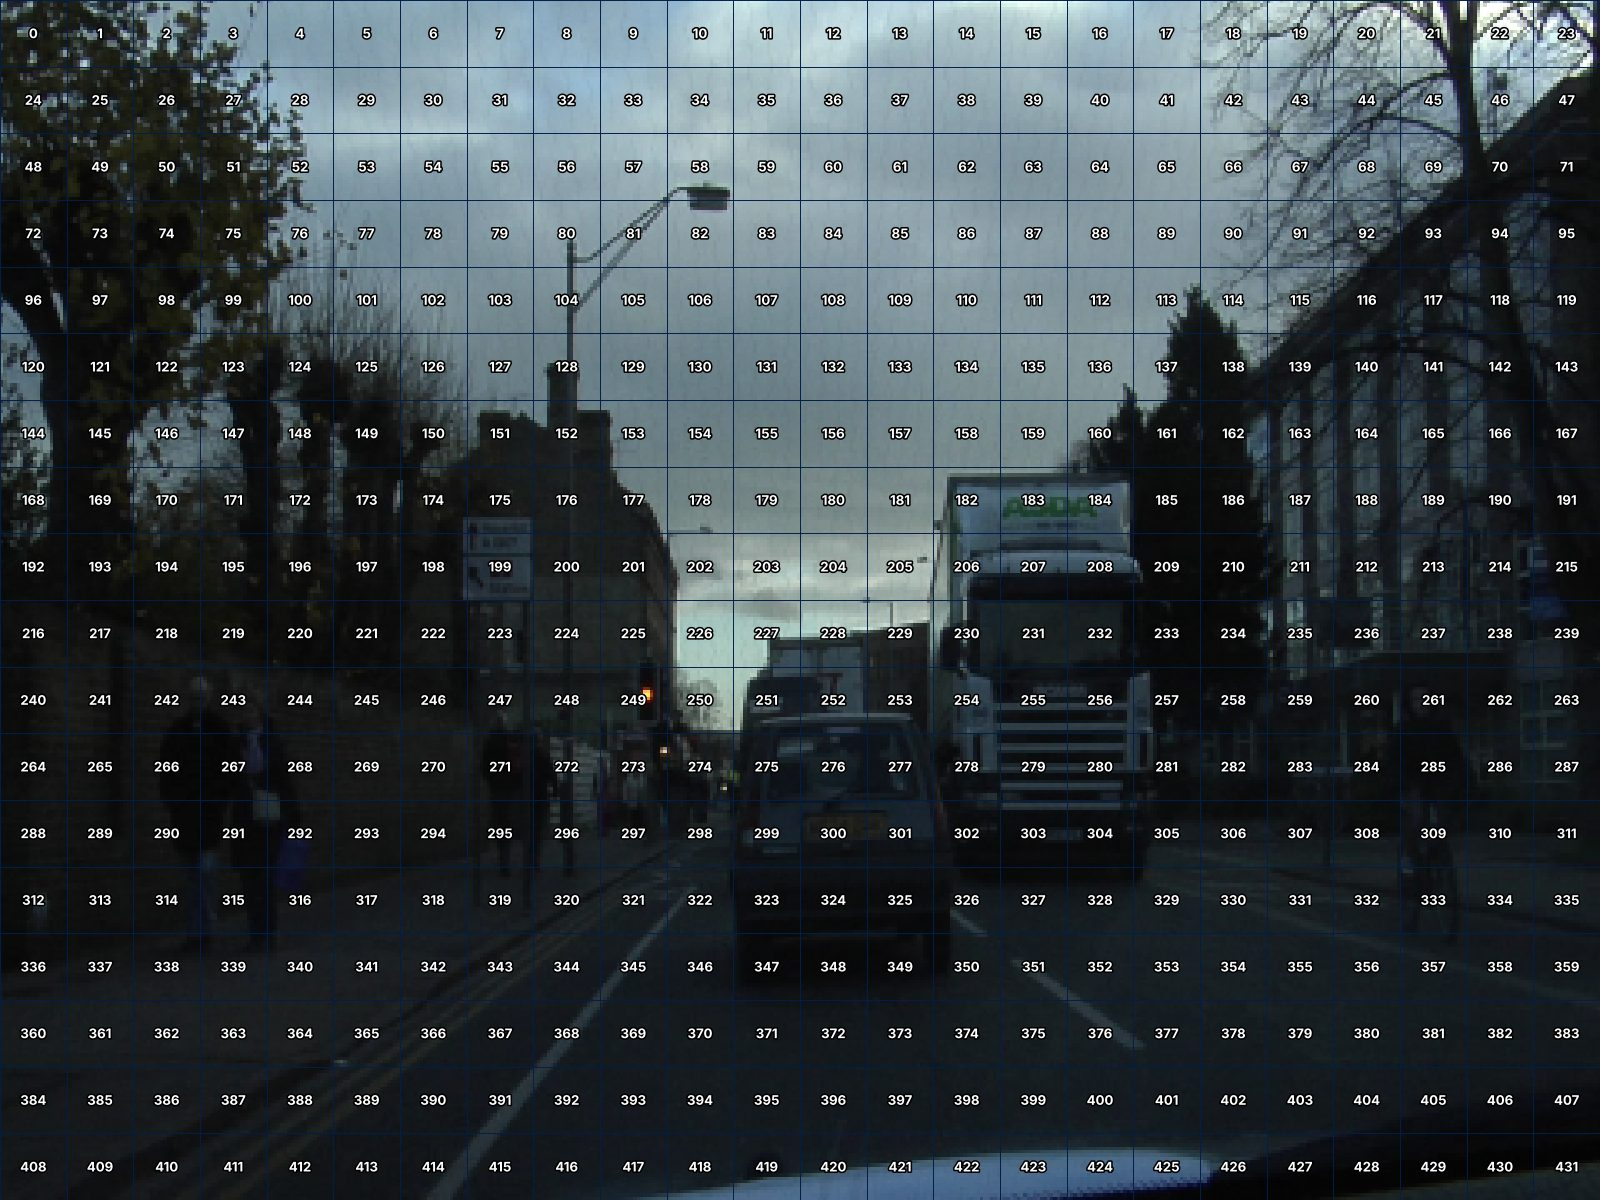
>
> `0001TP_008700`:
>
> 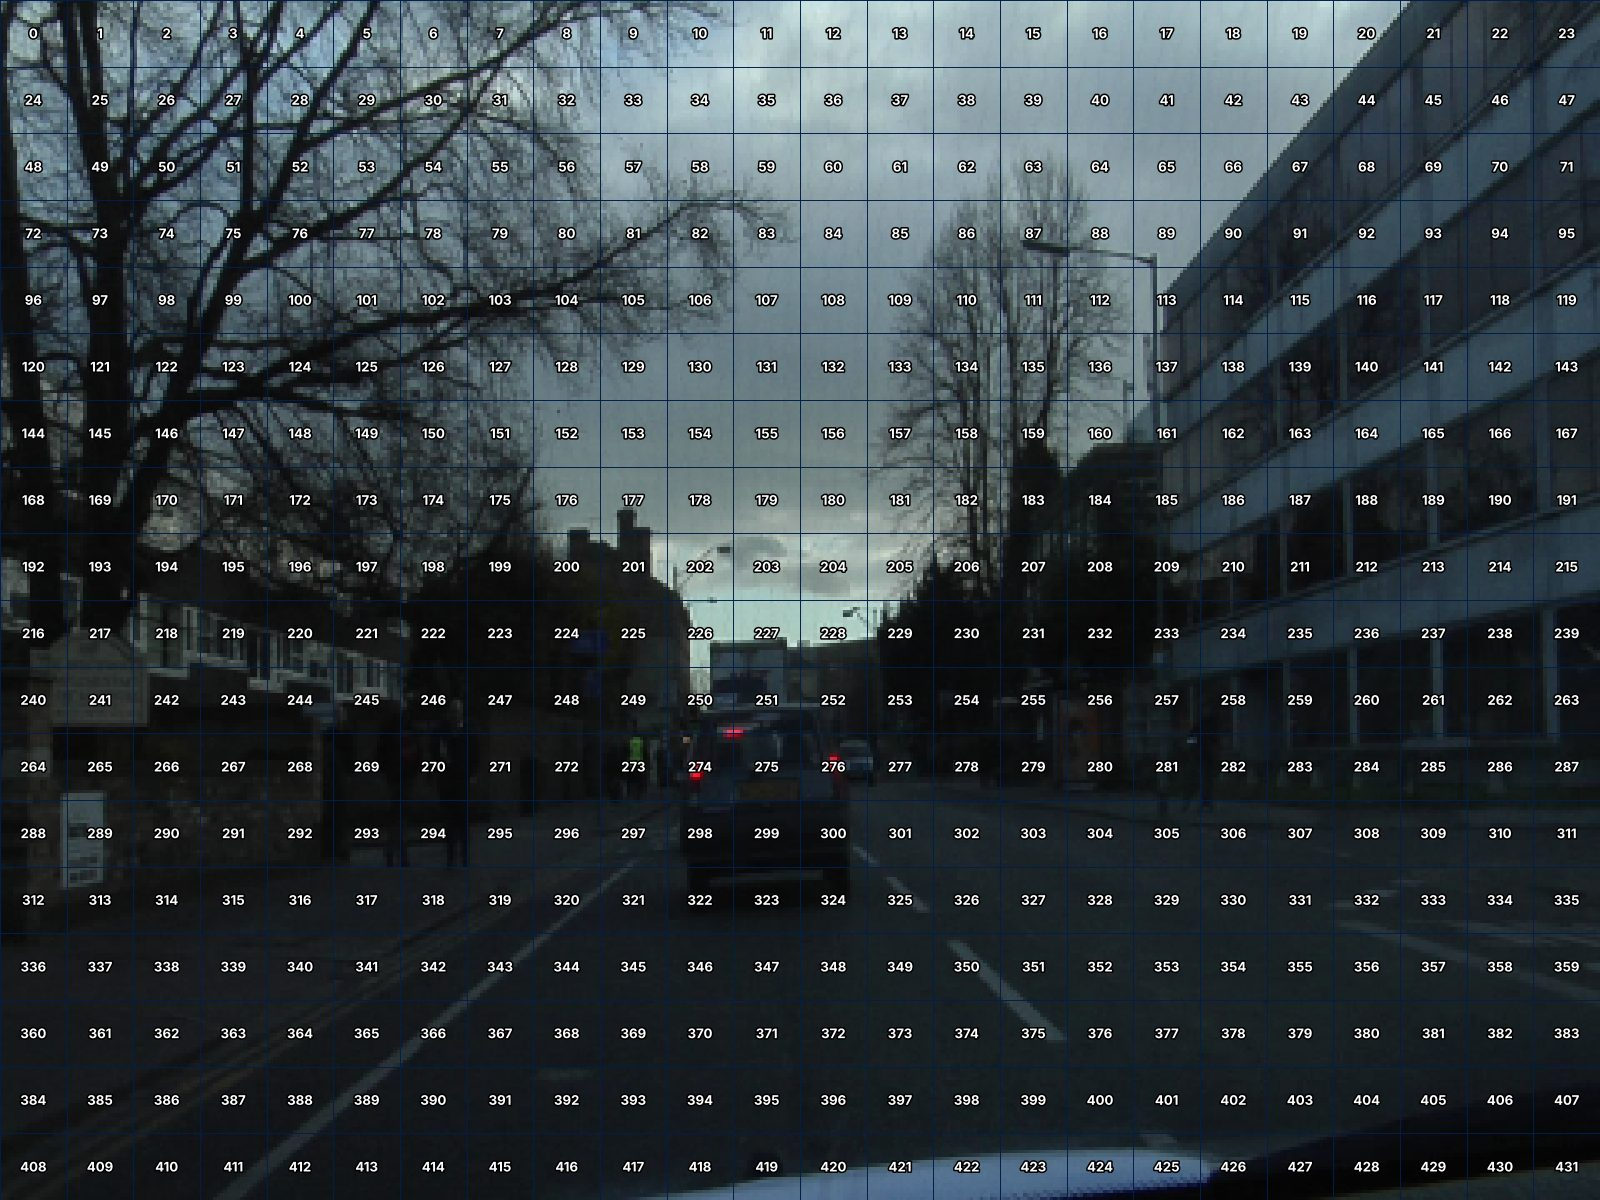
>
> **What to do:** add the features of your 12 patches (from `ADD_FROM`) to your 24 training patches.
> Set **`K_AFTER`** (start with your `CHOSEN_K`, then try 3 and 5 and keep the one you prefer). Label
> all four photographs again, store the scores in **`MULTI_AFTER`**, and print them beside
> `MULTI_BEFORE`.
>
> **What you should see:** the cloudy photograph you did **not** take patches from is the honest test.
> It rises from about 40% to about **70% to 90%**. The same-drive photographs may drop a few points,
> because cloudy sky is about as dark as sunny road and hedge.

## 10 &middot; The same with scikit-learn

**What to do**
1. Train `sklearn.neighbors.KNeighborsClassifier(n_neighbors=CHOSEN_K)` on `Xtr`, `ytr`, predict all 432
   patches of your photograph, and count how many labels agree with `MAP_PRED`.
2. Train it on your 36 patches (`Xtr` plus the 12 added) with `K_AFTER`, and score all five photographs.

**What you should see**
- scikit-learn agrees with your own k-NN on all, or nearly all, 432 patches. Any difference comes from
  how ties in the vote are broken.
- The scores on the four photographs match your `MULTI_AFTER`.

---

## Hand in

**What to do.** In the last cell, print **one line** that starts with the word `LAB07A`, then a space,
then a JSON dictionary (`json.dumps`) with these keys. Turn NumPy arrays and numbers into plain lists
and numbers first (`.tolist()`, `int()`, `float()`).

| key | value |
|:--|:--|
| `"bits_id"`, `"photo"`, `"THRESH"` | your BITS ID, `"Seq05VD_f01200"`, `20` |
| `"TRAIN"`, `"VAL"` | your patch numbers |
| `"F"` | `F` as 432 pairs of numbers, rounded to 4 decimals |
| `"VAL_ACC"`, `"CHOSEN_K"`, `"MAP_PRED"` | Section 7 |
| `"DISAGREE_PATCH"` | Section 6 |
| `"UNSCALED_ACC"`, `"L1_ACC"`, `"CHANGED_PATCH"` | Section 8 |
| `"ADD_FROM"`, `"ADD"`, `"K_AFTER"`, `"MULTI_BEFORE"`, `"MULTI_AFTER"` | Section 9 |
| `"EXPLORE_1"`, `"EXPLORE_6"` | your two sentences |

**What you should see:** one long line beginning `LAB07A {"bits_id": "2024A7PS0123U", "photo": "Seq05VD_f01200", "THRESH": 20, "TRAIN": {"sky": [...`

Then: **File &rarr; Download .ipynb**, rename to exactly **`lab07a.ipynb`**, upload it to your repository
`f459-<your BITS ID, lowercase>`, and check on GitHub that the `LAB07A` line is visible. If you change
anything, run the last cell again before downloading.

Then go on to **Notebook B**. You will need your `distances`, `knn_one` and `knn_predict` from Section 6.